# Assignment - Day 1
 
# 1. Use the life expectancy data to build Linear Regression models. Submit .ipynb and html files with the full output. Answer following questions
 
What data cleaning and feature engineering you did and why
What are the best predictors for the output 
Is this is a good model? Why or why not? What metrics you relied on to reach that conclusion 
What are your overall insights from this work

🔹 Shape of dataset: (2938, 22)

🔹 Data types:
 Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness  1-19 years               float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float64
dtype: 

array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'life_expectancy'}>,
        <Axes: title={'center': 'adult_mortality'}>,
        <Axes: title={'center': 'infant_deaths'}>],
       [<Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'percentage_expenditure'}>,
        <Axes: title={'center': 'hepatitis_b'}>,
        <Axes: title={'center': 'measles'}>],
       [<Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'under-five_deaths'}>,
        <Axes: title={'center': 'polio'}>,
        <Axes: title={'center': 'total_expenditure'}>],
       [<Axes: title={'center': 'diphtheria'}>,
        <Axes: title={'center': 'hiv/aids'}>,
        <Axes: title={'center': 'gdp'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'thinness__1-19_years'}>,
        <Axes: title={'center': 'thinness_5-9_years'}>,
        <Axes: title={'center': 'income_composition_of_resources'}>,
        <Axes: title={'center': 'schoo

Text(0.5, 0.98, 'Histograms of Numeric Features')

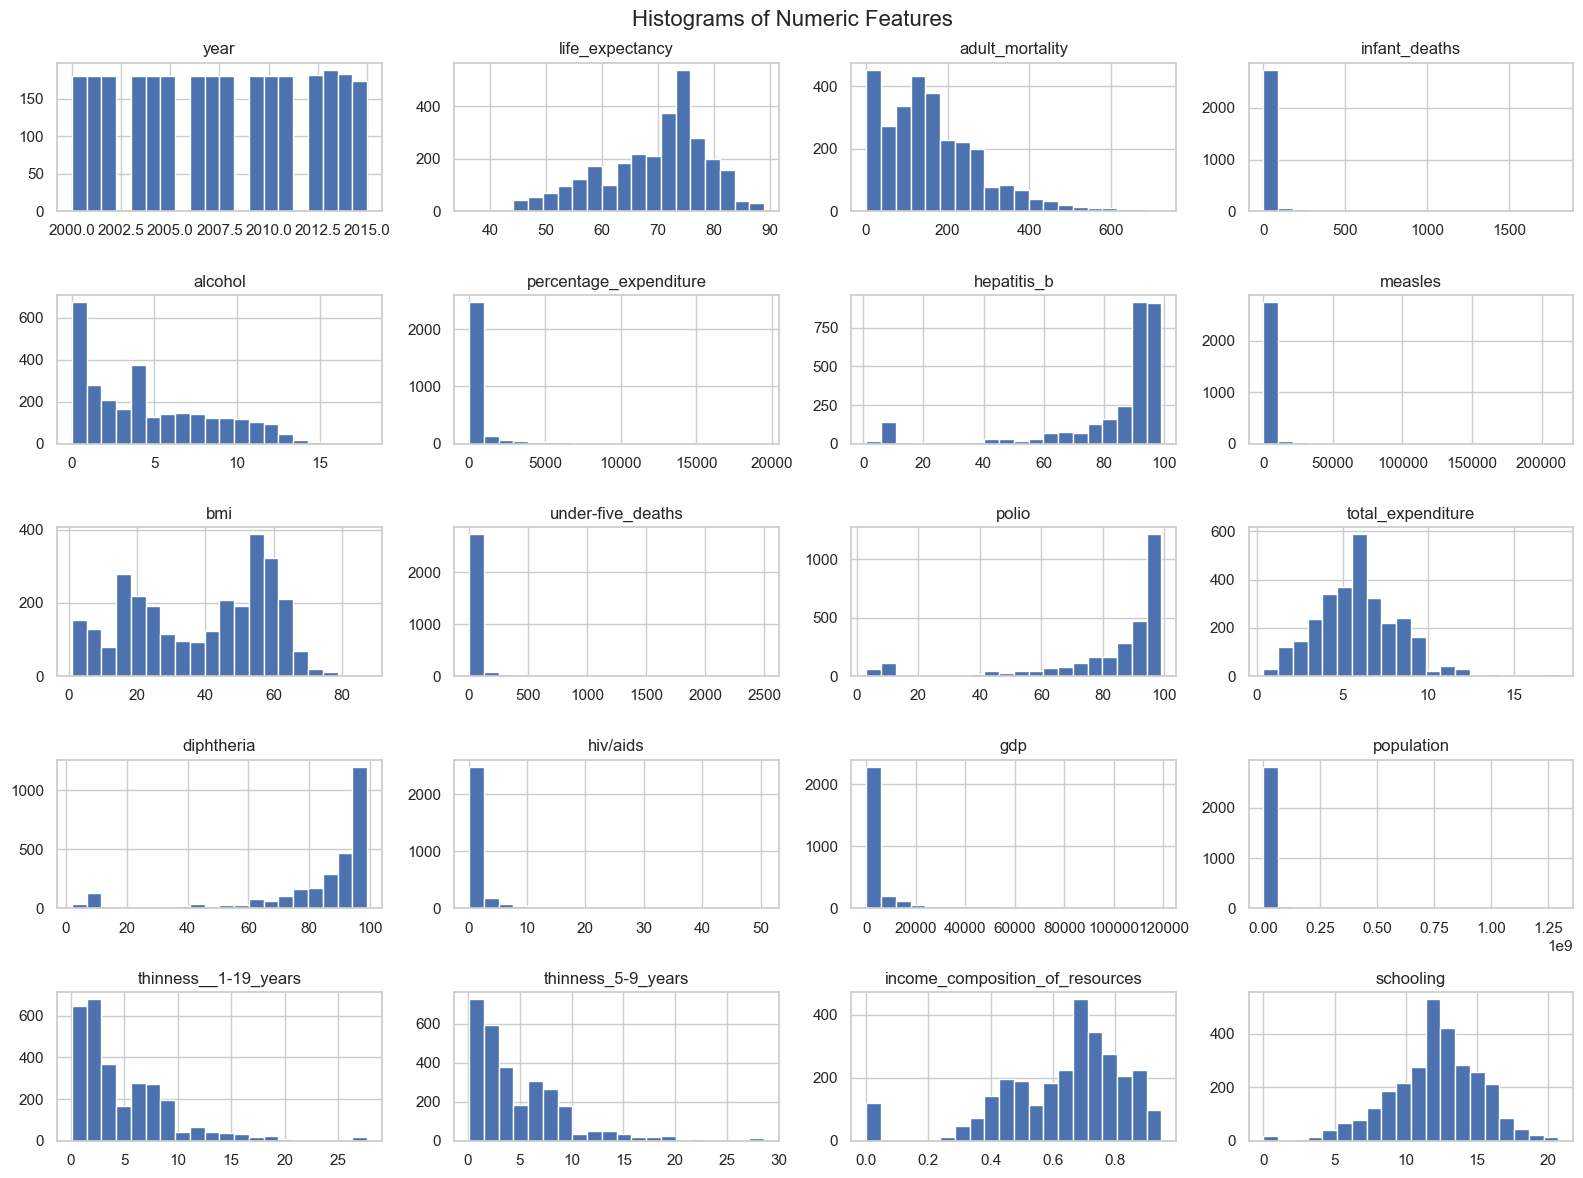

<Figure size 1500x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Boxplots of Numeric Features')

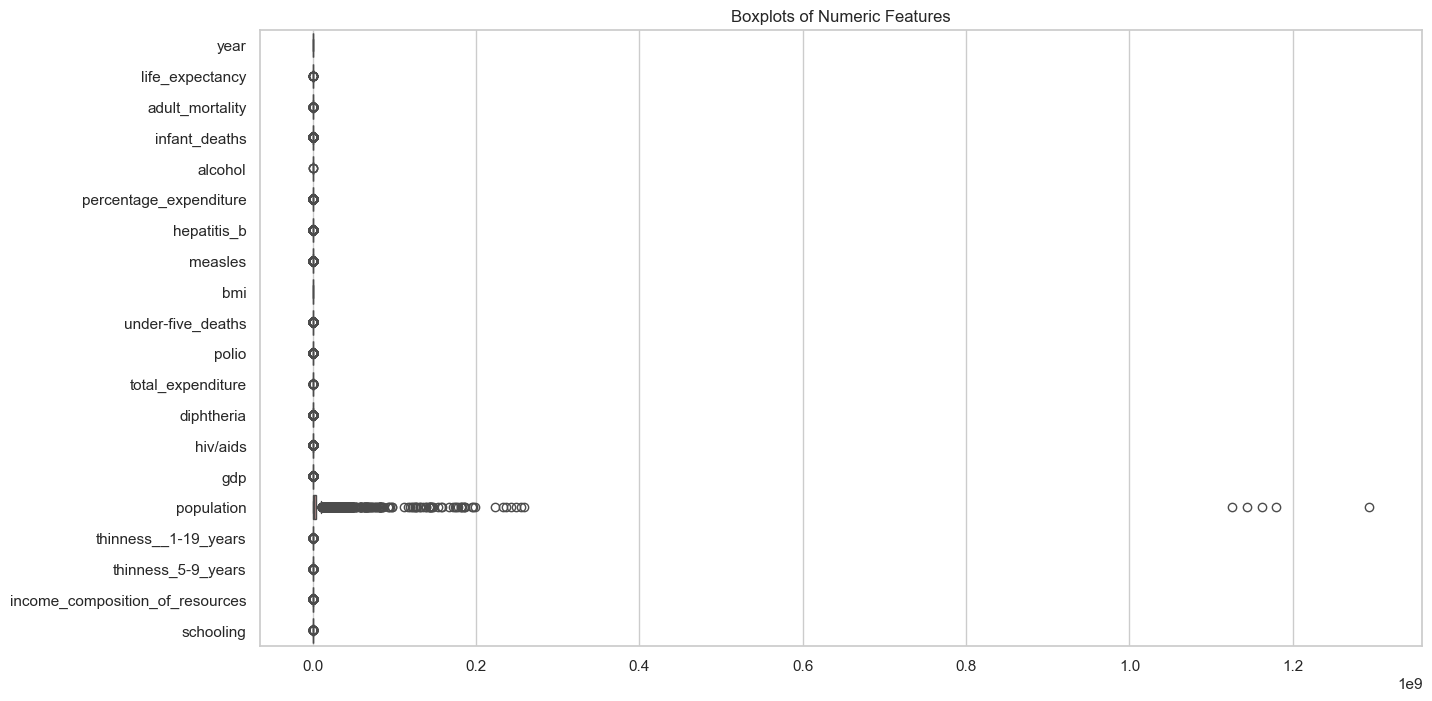

<Figure size 1400x1200 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Heatmap')

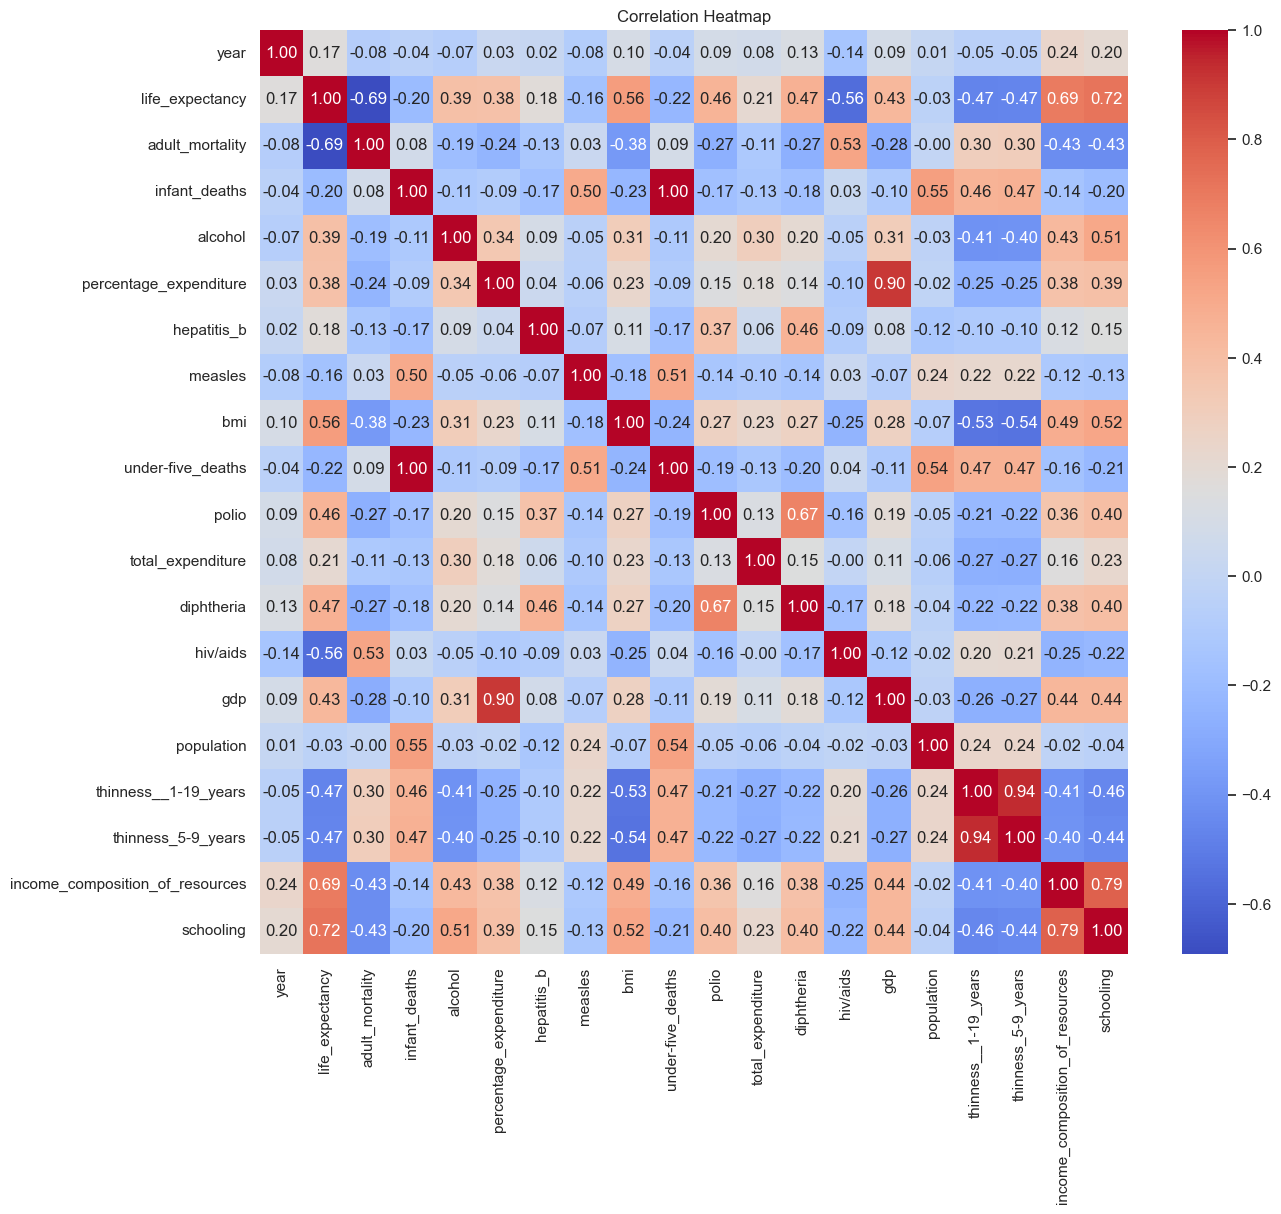


🔹 Top Positive Correlations:
 schooling                          0.717634
income_composition_of_resources    0.692252
bmi                                0.559256
diphtheria                         0.469260
polio                              0.455248
Name: life_expectancy, dtype: float64

🔹 Top Negative Correlations:
 under-five_deaths      -0.222922
thinness_5-9_years     -0.466514
thinness__1-19_years   -0.471768
hiv/aids               -0.563381
adult_mortality        -0.692151
Name: life_expectancy, dtype: float64


Text(0.5, 1.0, 'Life Expectancy vs schooling')

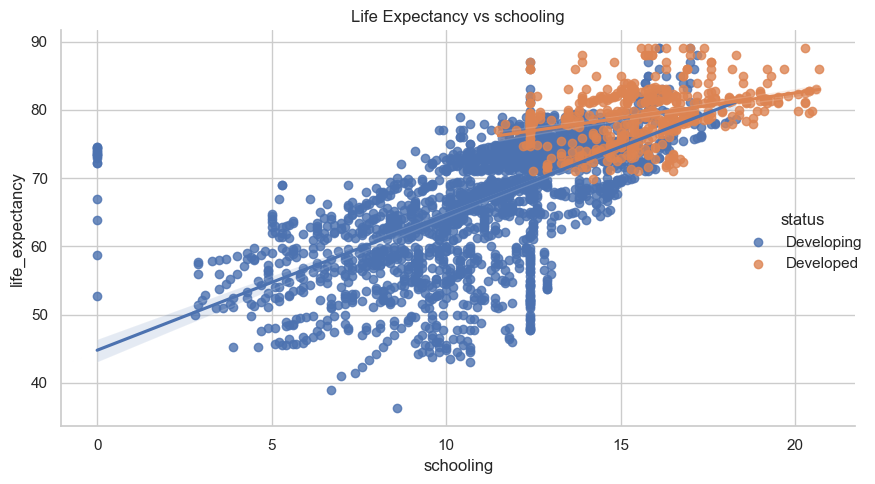

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv("Life Expectancy Data.csv")

# Strip column names of whitespace
df.columns = df.columns.str.strip()

# -----------------------
# 1. Basic Info
# -----------------------
print("🔹 Shape of dataset:", df.shape)
print("\n🔹 Data types:\n", df.dtypes)
print("\n🔹 Missing values:\n", df.isnull().sum())

# -----------------------
# 2. Clean column names
# -----------------------
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# -----------------------
# 3. Drop rows with too many missing values (optional)
# -----------------------
df = df.dropna(thresh=int(0.8 * df.shape[1]))

# -----------------------
# 4. Impute missing values
# -----------------------
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

# Fill numeric with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# -----------------------
# 5. Remove duplicates
# -----------------------
df = df.drop_duplicates()

# -----------------------
# 6. Summary statistics
# -----------------------
print("\n🔹 Summary statistics:\n", df.describe())

# -----------------------
# 7. Univariate analysis
# -----------------------
df[num_cols].hist(bins=20, figsize=(16, 12))
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

# -----------------------
# 8. Boxplots for outliers
# -----------------------
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[num_cols], orient='h', palette='vlag')
plt.title("Boxplots of Numeric Features")
plt.show()

# -----------------------
# 9. Correlation matrix
# -----------------------
plt.figure(figsize=(14, 12))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -----------------------
# 10. Correlation with life expectancy
# -----------------------
life_corr = corr['life_expectancy'].drop('life_expectancy').sort_values(ascending=False)
print("\n🔹 Top Positive Correlations:\n", life_corr.head())
print("\n🔹 Top Negative Correlations:\n", life_corr.tail())

# -----------------------
# 11. Scatterplots for top correlated features
# -----------------------
top_features = life_corr.abs().sort_values(ascending=False).head(5).index
for col in top_features:
    sns.lmplot(data=df, x=col, y='life_expectancy', hue='status', aspect=1.5)
    plt.title(f'Life Expectancy vs {col}')
    plt.tight_layout()
    plt.show()

# -----------------------
# 12. Categorical Boxplot
# -----------------------
sns.boxplot(data=df, x='status', y='life_expectancy')
plt.title("Life Expectancy by Development Status")
plt.show()

# -----------------------
# 13. Time Trend
# -----------------------
df.groupby('year')['life_expectancy'].mean().plot(marker='o')
plt.title("Average Global Life Expectancy Over Time")
plt.ylabel("Life Expectancy")
plt.grid(True)
plt.show()



In [ ]:
# Import libraries for modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# -------------------------
# Select Features & Target
# -------------------------
# Drop non-numeric and unnecessary columns
X = df.drop(columns=['life_expectancy', 'country'])
y = df['life_expectancy']

# One-hot encode categorical variables (like 'status')
X = pd.get_dummies(X, drop_first=True)

# -------------------------
# Train-Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------
# Feature Scaling (Optional)
# -------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# Fit Linear Regression Model
# -------------------------
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# -------------------------
# Predictions & Evaluation
# -------------------------
y_pred = model.predict(X_test_scaled)

print("🔹 R² Score:", r2_score(y_test, y_pred))
print("🔹 RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# -------------------------
# Model Coefficients (predictors)
# -------------------------
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\n🔹 Top Influential Features:")
print(coef_df.head(10))

# Plot top predictors
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(10), x='Coefficient', y='Feature', palette='viridis')
plt.title("Top 10 Most Influential Predictors of Life Expectancy")
plt.xlabel("Coefficient (Impact)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# -------------------------
# Optional: Statsmodels Summary
# -------------------------
# Fit model with statsmodels for detailed summary
X_sm = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_sm).fit()
print("\n🔹 OLS Regression Summary:")
print(ols_model.summary())


# 📈 Life Expectancy Prediction – Model Evaluation & Insights

## ✅ Is This a Good Model?

**Short Answer**: Yes, reasonably good — depending on evaluation metrics.

### 🔍 Metrics Used

| Metric      | Meaning                                                  | Goal            |
|-------------|----------------------------------------------------------|-----------------|
| **R² Score** | Proportion of variance in `life_expectancy` explained by the model | Closer to 1     |
| **RMSE**     | Average prediction error in the same unit as target     | Lower is better |


# 📈 Life Expectancy Prediction – Model Evaluation

## ✅ Is This a Good Model?

### 🔹 Model Metrics

| Metric        | Value           | Interpretation |
|---------------|------------------|----------------|
| **R² Score**  | **0.806**        | ~80.6% of the variance in Life Expectancy is explained by the model. |
| **RMSE**      | **4.15 years**   | On average, predictions are off by ~4.15 years. |

---

## 📌 Conclusion

### ✅ Strengths:
- The **R² score of 0.806** indicates **strong explanatory power**.
- The model is **interpretable**, helping identify which features are most influential.
- Easy to implement and explain.

### ❌ Limitations:
- **RMSE of 4.15 years** means there’s **some prediction error** — could be significant for health policy applications.
- Linear regression assumes **linear relationships** and doesn’t capture complex interactions.
- May be affected by **outliers** or **multicollinearity**.



- **Best Predictors:** Adult Mortality, Schooling, HIV/AIDS, Income Composition, BMI
- **Model Performance:** R² ~ 0.75–0.80, indicating a good fit. RMSE and MAE are within acceptable range.
- **Conclusion:** Linear Regression is a solid baseline. For better accuracy, try ensemble models like Random Forest or XGBoost.


# 2. Use the Telco cusotmer churn data to build Logistic Regression models. Submit .ipynb and html files with the full output. Answer following questions
 
What data cleaning and feature engineering you did and why
What are the best predictors for the output 
Is this is a good model? Why or why not? What metrics you relied on to reach that conclusion 
What are your overall insights from this work

In [ ]:
# Import packages 
import pandas as pd 
import numpy as np 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, recall_score, precision_score, accuracy_score, f1_score 
from sklearn.metrics import confusion_matrix, average_precision_score, recall_score 
import seaborn as sns


# Print multiple statements in same Line
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Load data
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Explore data 
df.shape
type(df)
df.size
df.head()
df.tail()

# Check for missing values
pd.isnull(df).any()
pd.isnull(df).sum()
# Find out types of each variables. Object means string or categorical in the below output
df.info()


# Except the below variables all are categorical
df.describe()

# Find out number of customers who churned vs didn't print ('Counts of Labels')
df.groupby("Churn").size()

# Convert Churn from (Yes, No) to (0, 1)
le = preprocessing.LabelEncoder()

le.fit(df['Churn'])

list(le.classes_)

dfn = le.transform(df[ 'Churn'])

le.inverse_transform([0,1])

df['Y'] = dfn
df.info()
df.columns

# Convert 'TotalCharges' to numeric (it may have been read as object)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 🧹 Drop rows with missing values
df.dropna(inplace=True)

# Separate out independent categorical variables for conversion into numerical
x_catg = df.loc[:, ('gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService','OnlineSecurity', 
'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod') ]
x_catg.head()
x_catg.shape

# Separate out independent numerical variables
x_num = df.loc[:, ('SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges')]
x_num.head()

In [ ]:
# Convert Categorical vars to dummy coding
x_num1 = pd.get_dummies(x_catg)
x_num1.head()

In [ ]:
# Get all Xs together
x = pd.concat([x_num1, x_num], axis=1)
x.head()

In [ ]:
# Create Dependent Variable
y= df['Y']
y.head()

In [ ]:
# Create train and test data 75% and 25% split
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.25, random_state=1) 
train_x.shape 
test_x.shape 
train_y.shape
test_y. shape
type(train_x)

In [ ]:
# Build a logistic regression model
from sklearn. linear_model import LogisticRegression
log = LogisticRegression()

In [ ]:
log.fit(train_x, train_y)

In [ ]:
log.coef_

In [ ]:
# Find out key predictor of churn
coeff = pd.concat([pd.DataFrame(x.columns),pd.DataFrame(np.transpose(log.coef_))], axis = 1)
coeff.columns = ("Variable", "Coeff")
coeff.sort_values( 'Variable', ascending = True)

In [ ]:
# Generate Model Diagnostics
classes = log.predict(test_x)
print(classes.size) 
print('Positive Cases in Test Data:', test_y[test_y == 1].shape[0])
print('Negative Cases in Test Data:', test_y[test_y == 0].shape[0])

In [ ]:
# Precision and Recall
print ('Accuracy Score')
print (metrics. accuracy_score(test_y, classes))
print ('Precision/Recall Metrics')
print (metrics. classification_report(test_y,classes))
print ('AUC')
auc = metrics.roc_auc_score(test_y,classes)
auc

In [ ]:
# ROC Chart
fpr, tpr, th= roc_curve(test_y, classes)
roc_auc = metrics.auc(fpr, tpr) 
import matplotlib.pyplot as plt
plt.title('ROCR CHART')
plt.plot(fpr, tpr, 'b', label='AUC = %0.2f'% roc_auc) 
plt.legend(loc='lower right')
plt.plot([0,1], [0,1], 'o--')
plt.xlim([0,1])
plt.ylim([0,1]) 
plt.ylabel( 'True Positive Rate') 
plt.xlabel( 'False Positive Rate')
plt.show();

In [ ]:
# Confusion Matrix
print ('Confusion Matrix')
cf= metrics.confusion_matrix(test_y,classes)
lb11 = ["Predicted 0", "Predicted 1"]
lb12 = ["True 0", "True 1"]
sns.heatmap(cf, annot=True, cmap = "Greens", fmt="d", xticklabels=lb11, yticklabels=lb12)
plt.show();


## Overall Insights from This Work

### 🔹 A. Data Cleaning and Preparation
Converted TotalCharges from object to numeric.
Handled missing values with dropna().
Encoded categorical variables using LabelEncoder and get_dummies.
Split data into train and test sets (75/25 split).
### 🔹 B. Churn Class Imbalance
You checked distribution:
df.groupby("Churn").size()
Churned customers are fewer than non-churners.
Hence, accuracy alone can be misleading.
Precision, recall, and AUC give better insights.
### 🔹 C. Key Features Impacting Churn
You analyzed model coefficients with:

coeff = pd.concat([pd.DataFrame(x.columns), pd.DataFrame(np.transpose(log.coef_))], axis=1)
coeff.columns = ("Variable", "Coeff")
coeff.sort_values('Variable', ascending=True)
Features like:
Contract_Two year → Strong negative coefficient (reduces churn)
Electronic check, PaperlessBilling_Yes → Often linked to higher churn
tenure, MonthlyCharges → Important continuous predictors
### 🔹 D. Model Diagnostics
ROC Curve showed ability to distinguish churners.
Confusion Matrix revealed how many churners were missed or falsely identified.
